# Model 2 - LSTM
## 1. Required Imports, Retrieve and Split Data

In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

ds = load_dataset("Adilbai/stock-dataset")
df = ds["train"].to_pandas()

TARGET_COL = "Future_Up_1d"

leakage_cols = [
    "Future_Return_1d", "Future_Up_1d", "Future_Category_1d",
    "Future_Return_5d", "Future_Up_5d", "Future_Category_5d",
    "Future_Return_10d", "Future_Up_10d", "Future_Category_10d",
    "Future_Return_20d", "Future_Up_20d", "Future_Category_20d",
]

id_cols = ["Date", "Ticker"]

feature_cols = []
for c in df.columns:
    if c in leakage_cols or c in id_cols:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        feature_cols.append(c)

# Drop missing rows
df = df.dropna(subset=feature_cols + [TARGET_COL, "Ticker", "Date"]).copy()

# Sort properly
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Num rows:", len(df))
print("Num features:", len(feature_cols))

# ---- split date based on full panel time ----
split_date = df["Date"].quantile(0.9)
print("Split date:", split_date)

# ---- fit normalization on TRAIN ROWS ONLY ----
train_mask = df["Date"] <= split_date

train_mean = df.loc[train_mask, feature_cols].mean()
train_std  = df.loc[train_mask, feature_cols].std().replace(0, 1.0)

# normalize full df using train stats
df_norm = df.copy()
df_norm[feature_cols] = (df_norm[feature_cols] - train_mean) / train_std


class StockSequenceDataset(Dataset):
    def __init__(self, data: pd.DataFrame, feature_cols, target_col, split_date, seq_len=20, split="train"):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len
        self.split = split
        self.split_date = pd.Timestamp(split_date)

        self.groups = []
        self.indices = []

        # build groups ticker by ticker
        for ticker, g in data.groupby("Ticker", sort=False):
            g = g.sort_values("Date").reset_index(drop=True)

            if len(g) < seq_len:
                continue

            group_id = len(self.groups)
            self.groups.append(g)

            # build all possible windows from full ticker history
            for end in range(seq_len - 1, len(g)):
                label_date = g.loc[end, "Date"]

                if split == "train" and label_date <= self.split_date:
                    self.indices.append((group_id, end))

                elif split == "val" and label_date > self.split_date:
                    self.indices.append((group_id, end))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        gi, end = self.indices[idx]
        g = self.groups[gi]

        start = end - self.seq_len + 1

        x = g.loc[start:end, self.feature_cols].to_numpy(dtype=np.float32)
        y = np.float32(g.loc[end, self.target_col])

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


SEQ_LEN = 20
BATCH_SIZE = 256

train_dataset = StockSequenceDataset(
    df_norm,
    feature_cols,
    TARGET_COL,
    split_date=split_date,
    seq_len=SEQ_LEN,
    split="train"
)

val_dataset = StockSequenceDataset(
    df_norm,
    feature_cols,
    TARGET_COL,
    split_date=split_date,
    seq_len=SEQ_LEN,
    split="val"
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train sequences:", len(train_dataset))
print("Val sequences:", len(val_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
/tmp/ipykernel_20137/3488457038.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


Num rows: 620095
Num features: 59
Split date: 2024-12-27 00:00:00-05:00
Train sequences: 548669
Val sequences: 61869


## 2. Create and train LSTM Model

In [2]:
class LSTMClassifier(nn.Module):
    def __init__(self, num_features, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last = out[:, -1, :]
        logits = self.fc(last).squeeze(1)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    num_features=len(feature_cols),
    hidden_dim=64,
    num_layers=2,
    dropout=0.2
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader.dataset), correct / total

In [4]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")
best_model_state = None
patience = 3
counter = 0
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 01 | Train Loss: 0.6922 | Train Acc: 0.5189 | Val Loss: 0.6919 | Val Acc: 0.5209
Epoch 02 | Train Loss: 0.6919 | Train Acc: 0.5198 | Val Loss: 0.6920 | Val Acc: 0.5161
Epoch 03 | Train Loss: 0.6916 | Train Acc: 0.5215 | Val Loss: 0.6920 | Val Acc: 0.5185
Epoch 04 | Train Loss: 0.6912 | Train Acc: 0.5246 | Val Loss: 0.6921 | Val Acc: 0.5142
Early stopping triggered.


## 3. Plot LSTM Model Results

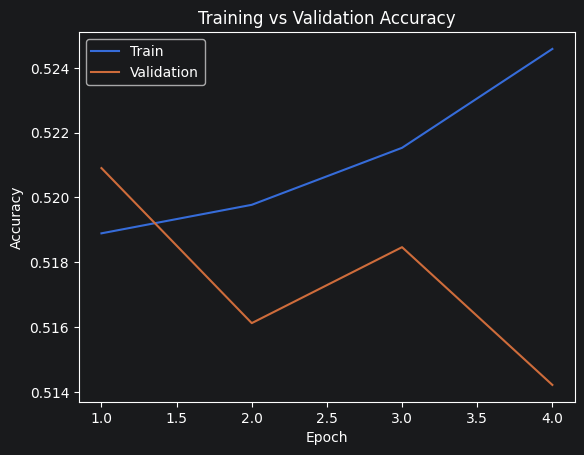

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

plt.figure()
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# XGBoost Model

/tmp/ipykernel_20137/2222678500.py:42: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


Num rows: 620095
Num features: 59
Split date: 2024-12-27 00:00:00-05:00
Train sequences: 548669
Val sequences:   61869
Device: cuda
Epoch 01 | Train Loss: 1.1001 | Train Acc: 0.5414 | Val Loss: 1.1076 | Val Acc: 0.5193
Epoch 02 | Train Loss: 1.0857 | Train Acc: 0.5696 | Val Loss: 1.1212 | Val Acc: 0.5141
Epoch 03 | Train Loss: 1.0656 | Train Acc: 0.5930 | Val Loss: 1.1346 | Val Acc: 0.5107
Epoch 04 | Train Loss: 1.0461 | Train Acc: 0.6156 | Val Loss: 1.1532 | Val Acc: 0.5111
Epoch 05 | Train Loss: 1.0271 | Train Acc: 0.6341 | Val Loss: 1.1692 | Val Acc: 0.5073
Epoch 06 | Train Loss: 1.0086 | Train Acc: 0.6510 | Val Loss: 1.2041 | Val Acc: 0.4936
Early stopping triggered.

Loaded best model — val loss: 1.1076


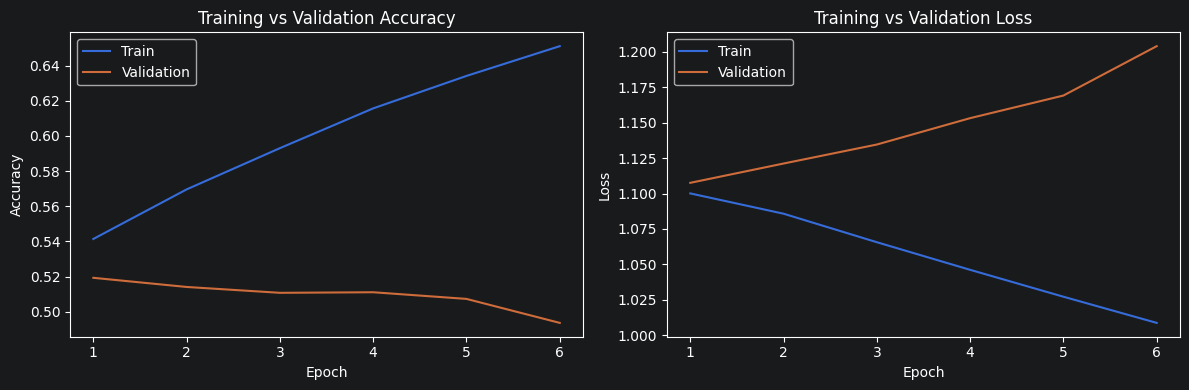

In [6]:
# ─────────────────────────────────────────────
#  1 — Imports & data loading
# ─────────────────────────────────────────────
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

ds = load_dataset("Adilbai/stock-dataset")
df = ds["train"].to_pandas()

TARGET_COL = "Future_Up_5d"

# Future_Up_1d and Future_Up_10d are kept
leakage_cols = [
    "Future_Return_1d", "Future_Category_1d",
    "Future_Return_5d", "Future_Up_5d", "Future_Category_5d",
    "Future_Return_10d", "Future_Category_10d",
    "Future_Return_20d", "Future_Up_20d", "Future_Category_20d",
]

id_cols = ["Date", "Ticker"]

feature_cols = []
for c in df.columns:
    if c in leakage_cols or c in id_cols:
        continue
    if c in ["Future_Up_1d", "Future_Up_10d"]:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        feature_cols.append(c)

# Drop missing rows
df = df.dropna(subset=feature_cols + [TARGET_COL, "Future_Up_1d", "Future_Up_10d", "Ticker", "Date"]).copy()

# Sort properly
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Num rows:", len(df))
print("Num features:", len(feature_cols))

# 90/10 date split
split_date = df["Date"].quantile(0.9)
print("Split date:", split_date)


# ─────────────────────────────────────────────
#  2 — prepare_dataframe
# ─────────────────────────────────────────────

def prepare_dataframe(df, feature_cols, TARGET_COL, split_date):
    ret_col = None
    for c in ["Return_1d", "Daily_Return", "Close_Return", "ret"]:
        if c in df.columns:
            ret_col = c
            break

    if ret_col:
        df = df.copy()
        df["feat_vol10"] = (
            df.groupby("Ticker")[ret_col]
              .transform(lambda s: s.rolling(10, min_periods=5).std())
        )
        df["feat_mom5z"] = (
            df.groupby("Ticker")[ret_col]
              .transform(lambda s: s.rolling(5).mean() / (s.rolling(5).std() + 1e-8))
        )
        for f in ["feat_vol10", "feat_mom5z"]:
            if df[f].notna().mean() > 0.5 and f not in feature_cols:
                feature_cols.append(f)
        df = df.dropna(subset=feature_cols + [TARGET_COL]).copy()

    train_mask = df["Date"] <= split_date
    train_mean = df.loc[train_mask, feature_cols].mean()
    train_std  = df.loc[train_mask, feature_cols].std().replace(0, 1.0)
    df_norm    = df.copy()
    df_norm[feature_cols] = (df_norm[feature_cols] - train_mean) / train_std

    return df_norm, feature_cols

df_norm, feature_cols = prepare_dataframe(df, feature_cols, TARGET_COL, split_date)


# ─────────────────────────────────────────────
#  3 — Dataset
# ─────────────────────────────────────────────

class StockSequenceDataset(Dataset):
    def __init__(self, data, feature_cols, target_col, split_date, seq_len=20, split="train"):
        self.feature_cols = feature_cols
        self.target_col   = target_col
        self.seq_len      = seq_len
        self.split_date   = pd.Timestamp(split_date)

        self.groups  = []
        self.indices = []

        for ticker, g in data.groupby("Ticker", sort=False):
            g = g.sort_values("Date").reset_index(drop=True)
            if len(g) < seq_len:
                continue

            gid = len(self.groups)
            self.groups.append(g)

            for end in range(seq_len - 1, len(g)):
                label_date = g.loc[end, "Date"]
                if split == "train" and label_date <= self.split_date:
                    self.indices.append((gid, end))
                elif split == "val" and label_date > self.split_date:
                    self.indices.append((gid, end))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        gi, end = self.indices[idx]
        g       = self.groups[gi]
        start   = end - self.seq_len + 1

        x   = g.loc[start:end, self.feature_cols].to_numpy(dtype=np.float32)
        y5  = np.float32(g.loc[end, self.target_col])
        y1  = np.float32(g.loc[end, "Future_Up_1d"])  if "Future_Up_1d"  in g.columns else y5
        y10 = np.float32(g.loc[end, "Future_Up_10d"]) if "Future_Up_10d" in g.columns else y5

        return (torch.from_numpy(x),
                torch.tensor(y1,  dtype=torch.float32),
                torch.tensor(y5,  dtype=torch.float32),
                torch.tensor(y10, dtype=torch.float32))


# ─────────────────────────────────────────────
#  4 — Model building blocks
# ─────────────────────────────────────────────

class GatedLinearUnit(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d, d * 2)

    def forward(self, x):
        a, b = self.fc(x).chunk(2, dim=-1)
        return a * torch.sigmoid(b)


class GatedResidualNetwork(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, dropout=0.1):
        super().__init__()
        self.proj_in  = nn.Linear(d_in, d_hidden)
        self.proj_ctx = nn.Linear(d_hidden, d_hidden, bias=False)
        self.fc1      = nn.Linear(d_hidden, d_hidden)
        self.glu      = GatedLinearUnit(d_hidden)
        self.fc_out   = nn.Linear(d_hidden, d_out)
        self.skip     = nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity()
        self.norm     = nn.LayerNorm(d_out)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x, context=None):
        residual = self.skip(x)

        h = F.elu(self.proj_in(x))
        if context is not None:
            h = h + self.proj_ctx(context)

        h = self.fc1(h)
        h = self.drop(self.glu(h))
        h = self.fc_out(h)

        h = self.norm(h + residual)
        return h


class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_features, d_model, dropout=0.1):
        super().__init__()
        self.grns = nn.ModuleList([
            GatedResidualNetwork(1, d_model, d_model, dropout)
            for _ in range(num_features)
        ])
        self.softmax_grn = GatedResidualNetwork(num_features, d_model, num_features, dropout)

    def forward(self, x):
        B, T, F = x.shape
        xi   = [self.grns[i](x[:, :, i:i+1]) for i in range(F)]
        xi   = torch.stack(xi, dim=-1)
        flat = x.reshape(B * T, F)
        w    = torch.softmax(
            self.softmax_grn(flat.unsqueeze(1)).squeeze(1), dim=-1
        )
        w    = w.reshape(B, T, F)
        out  = (xi * w.unsqueeze(2)).sum(dim=-1)
        return out, w


class TemporalFusionTransformer(nn.Module):
    def __init__(self, num_features, d_model=128, lstm_layers=2, attn_heads=4, dropout=0.3):
        super().__init__()
        self.vsn      = VariableSelectionNetwork(num_features, d_model, dropout)
        self.lstm     = nn.LSTM(d_model, d_model, lstm_layers,
                                batch_first=True,
                                dropout=dropout if lstm_layers > 1 else 0.0)
        self.attn     = nn.MultiheadAttention(d_model, attn_heads,
                                              dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(d_model)
        self.grn_out  = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.out_norm = nn.LayerNorm(d_model)

        self.head_1d  = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(),
                                      nn.Dropout(dropout), nn.Linear(32, 1))
        self.head_5d  = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(),
                                      nn.Dropout(dropout), nn.Linear(32, 1))
        self.head_10d = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(),
                                      nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        h, _  = self.vsn(x)
        h, _  = self.lstm(h)
        a, _  = self.attn(h, h, h)
        h     = self.attn_norm(h + a)
        h     = self.grn_out(h)
        h     = self.out_norm(h)
        last  = h[:, -1, :]
        return (self.head_1d(last).squeeze(1),
                self.head_5d(last).squeeze(1),
                self.head_10d(last).squeeze(1))


# ─────────────────────────────────────────────
#  5 — Loss & training functions
# ─────────────────────────────────────────────

class LabelSmoothBCELoss(nn.Module):
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)


def train_one_epoch(model, loader, optimizer, criterion, device, aux_weight=0.3):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y1, y5, y10 in loader:
        x, y1, y5, y10 = (t.to(device) for t in (x, y1, y5, y10))
        optimizer.zero_grad()
        logit_1d, logit_5d, logit_10d = model(x)
        loss = (criterion(logit_5d, y5)
                + aux_weight * criterion(logit_1d,  y1)
                + aux_weight * criterion(logit_10d, y10))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds       = (torch.sigmoid(logit_5d) > 0.5).float()
        correct    += (preds == y5).sum().item()
        total      += y5.size(0)

    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device, aux_weight=0.3):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y1, y5, y10 in loader:
        x, y1, y5, y10 = (t.to(device) for t in (x, y1, y5, y10))
        logit_1d, logit_5d, logit_10d = model(x)
        loss = (criterion(logit_5d, y5)
                + aux_weight * criterion(logit_1d,  y1)
                + aux_weight * criterion(logit_10d, y10))

        total_loss += loss.item() * x.size(0)
        preds       = (torch.sigmoid(logit_5d) > 0.5).float()
        correct    += (preds == y5).sum().item()
        total      += y5.size(0)

    return total_loss / len(loader.dataset), correct / total


# ─────────────────────────────────────────────
#  6 — DataLoaders, model, optimizer
# ─────────────────────────────────────────────

SEQ_LEN    = 20
BATCH_SIZE = 256

train_dataset = StockSequenceDataset(
    df_norm, feature_cols, TARGET_COL,
    split_date=split_date, seq_len=SEQ_LEN, split="train"
)
val_dataset = StockSequenceDataset(
    df_norm, feature_cols, TARGET_COL,
    split_date=split_date, seq_len=SEQ_LEN, split="val"
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Train sequences:", len(train_dataset))
print("Val sequences:  ", len(val_dataset))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = TemporalFusionTransformer(
    num_features = len(feature_cols),
    d_model      = 128,
    lstm_layers  = 2,
    attn_heads   = 4,
    dropout      = 0.3,
).to(device)

criterion = LabelSmoothBCELoss(smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)


# ─────────────────────────────────────────────
#  7 — Train
# ─────────────────────────────────────────────

EPOCHS        = 40
patience      = 5
best_val_loss = float("inf")
best_model_state = None
counter       = 0

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = eval_one_epoch(model,  val_loader,   criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        torch.save(best_model_state, "best_tft_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model — val loss: {best_val_loss:.4f}")


# ─────────────────────────────────────────────
#  8 — Plot
# ─────────────────────────────────────────────

epochs_range = range(1, len(train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_accs, label="Train")
ax1.plot(epochs_range, val_accs,   label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training vs Validation Accuracy")
ax1.legend()

ax2.plot(epochs_range, train_losses, label="Train")
ax2.plot(epochs_range, val_losses,   label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training vs Validation Loss")
ax2.legend()

plt.tight_layout()
plt.show()